# ADS1001 Project Report Notebook

**Project title:** Communicating Useful Weather Indicators for Public Weather Guidance in Malaysia

**Group members:**

- Member 1: ____________________
- Member 2: ____________________
- Member 3: ____________________
- Member 4: ____________________
- Member 5: ____________________


## Project Background

Malaysia's public weather communication needs indicators that are understandable, reliable, and connected to practical action. The cleaned dataset used in this notebook contains Malaysian weather observations with location, time, temperature, humidity, dew point, pressure, wind, rainfall, wind chill, and UV Index variables.

This final report integrates the five group notebooks into one coherent analysis. The aim is not to report every variable equally, but to decide which indicators are most useful for a public-facing weather information service.

**Integrated source notebooks:**

| Source notebook | Contribution to this final notebook |
|---|---|
| `malaysia_weather_data_cleaning_process.ipynb` | Cleaning process and validation logic |
| `ADS1001 notebook Q1.ipynb` | Temperature versus wind chill analysis |
| `weather_project.ipynb` | Humidity, dew point, and oppressive weather analysis |
| `ADS1001_updated_with_cleaned_data.ipynb` | Atmospheric pressure, pressure trend, and rainfall analysis |
| `xu_zihao_uv_index_analysis.ipynb` | UV Index risk categories and public warning thresholds |


## 1. Research Questions and Objectives

The shared objective is to evaluate weather indicators for public guidance in Malaysia. Each section below answers one research question and ends with a short conclusion.

**Research questions**

1. How different are temperature and wind chill readings in Malaysia, and does wind chill add practical value beyond temperature?
2. How strongly are humidity and dew point associated, and which variable better describes oppressive, sticky weather?
3. How are atmospheric pressure and pressure changes associated with rainfall, and can pressure trend support short-term rain guidance?
4. Which weather conditions correspond to high UV Index values, and what threshold should trigger public UV warnings?

**Overall hypothesis:** Temperature, dew point, pressure trend, rainfall, and UV Index each contribute different information. Wind chill is expected to add little value in a tropical climate, while dew point and UV Index are expected to be more useful for public warnings and guidance.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

try:
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        average_precision_score,
        confusion_matrix,
    )
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PROJECT_ROOT = Path.cwd()


## 2. Data Loading

The analysis uses the cleaned CSV supplied for the final report: `malaysia_weather_cleaned_file.csv`. The notebook first searches inside the project `data` folder so it can be rerun after submission.


In [2]:
EXPECTED_COLUMNS = {
    'place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity',
    'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate',
    'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds',
    'month_number', 'datetime'
}

candidate_paths = [
    PROJECT_ROOT / 'data' / 'malaysia_weather_cleaned_file.csv',
    PROJECT_ROOT / 'data' / 'malaysia_weather_cleaned_file(3).csv',
    PROJECT_ROOT / 'malaysia_weather_cleaned_file.csv',
    Path('/Users/c2/Desktop/malaysia_weather_cleaned_file(3).csv'),
]


def load_cleaned_weather_csv(paths):
    """Load the cleaned weather CSV from the first valid path in a candidate list."""
    for path in paths:
        if path.exists():
            df_candidate = pd.read_csv(path, low_memory=False)
            if EXPECTED_COLUMNS.issubset(set(df_candidate.columns)):
                return path, df_candidate
            raise ValueError(f'Found {path}, but it does not contain the expected cleaned weather columns.')
    raise FileNotFoundError('Cleaned weather CSV not found. Place malaysia_weather_cleaned_file.csv in the data folder.')

DATA_PATH, weather = load_cleaned_weather_csv(candidate_paths)
print(f'Loaded cleaned dataset from: {DATA_PATH}')
print(f'Cleaned dataset shape: {weather.shape}')
display(weather.head())


Loaded cleaned dataset from: /Users/c2/Library/CloudStorage/GoogleDrive-zche0400@student.monash.edu/My Drive/ADS1001/project/MWF-G2/data/malaysia_weather_cleaned_file.csv
Cleaned dataset shape: (51693, 21)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds,month_number,datetime
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.300,"1,015.325",25.100,73.700,0.900,1.500,30.300,1.000,0.000,0.000,2022,Sep,23,13,54,57,9,2022-09-23 13:54:57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.000,"1,000.680",25.600,92.000,5.200,5.300,27.000,0.000,0.000,17.780,2023,May,4,19,9,59,5,2023-05-04 19:09:59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.400,"1,013.550",26.300,99.000,0.000,0.000,26.400,0.000,0.000,32.000,2021,Oct,23,23,44,43,10,2021-10-23 23:44:43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.100,"1,005.420",30.900,99.000,0.000,0.000,31.100,0.000,0.000,0.000,2021,Mar,21,18,9,47,3,2021-03-21 18:09:47
4,Penang Road,George Town,Pulau Pinang,25.800,"1,007.790",23.900,88.000,6.400,16.100,25.800,0.000,0.000,0.000,2022,Dec,22,7,0,23,12,2022-12-22 07:00:23


**Data loading conclusion:** The notebook loads the cleaned dataset directly. This satisfies the final-report requirement that the code produces the results shown in the notebook, while avoiding dependence on a raw desktop-only file.


## 3. Data Dictionary

The table below documents the variables used in the integrated analysis.


In [3]:
data_dictionary = pd.DataFrame({
    'Column': [
        'place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity',
        'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate',
        'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds',
        'month_number', 'datetime'
    ],
    'Type': [
        'Categorical', 'Categorical', 'Categorical', 'Numerical', 'Numerical', 'Numerical',
        'Numerical', 'Numerical', 'Numerical', 'Numerical', 'Numerical', 'Numerical',
        'Numerical', 'Integer', 'Categorical', 'Integer', 'Integer', 'Integer', 'Integer',
        'Integer', 'Date/Time'
    ],
    'Meaning': [
        'Specific observation place or station label',
        'City where the observation was recorded',
        'State where the observation was recorded',
        'Air temperature in degrees C',
        'Atmospheric pressure in hPa',
        'Dew point temperature in degrees C',
        'Relative humidity percentage',
        'Wind speed',
        'Wind gust speed',
        'Wind chill reading in degrees C',
        'Ultraviolet radiation index',
        'Current precipitation intensity',
        'Accumulated precipitation total',
        'Observation year',
        'Three-letter month label',
        'Day of month',
        'Hour of day, 0 to 23',
        'Minute of observation',
        'Second of observation',
        'Numeric month created during cleaning',
        'Combined timestamp created during cleaning'
    ],
    'Role in project': [
        'Location grouping', 'Location grouping', 'Location grouping',
        'Thermal and UV context', 'Rainfall and pressure analysis',
        'Oppressive weather indicator', 'Moisture and heat context',
        'Wind chill and rainfall context', 'Outdoor condition context',
        'Comparison with temperature', 'UV warning analysis',
        'Rainfall event analysis', 'Rainfall event analysis',
        'Time coverage', 'Time coverage', 'Time coverage', 'Hourly patterns',
        'Timestamp construction', 'Timestamp construction', 'Timestamp construction',
        'Time-series analysis'
    ]
})
data_dictionary


,Column,Type,Meaning,Role in project
0,place,Categorical,Specific observation place or station label,Location grouping
1,city,Categorical,City where the observation was recorded,Location grouping
2,state,Categorical,State where the observation was recorded,Location grouping
3,temperature,Numerical,Air temperature in degrees C,Thermal and UV context
4,pressure,Numerical,Atmospheric pressure in hPa,Rainfall and pressure analysis
5,dew_point,Numerical,Dew point temperature in degrees C,Oppressive weather indicator
6,humidity,Numerical,Relative humidity percentage,Moisture and heat context
7,wind_speed,Numerical,Wind speed,Wind chill and rainfall context
8,gust,Numerical,Wind gust speed,Outdoor condition context
9,wind_chill,Numerical,Wind chill reading in degrees C,Comparison with temperature


## 4. Data Cleaning and Validation

The raw-to-cleaned process was completed in the cleaning notebook before this final report. This notebook validates the supplied cleaned file before using it for analysis.

Important interpretation note: because this final CSV has already been cleaned and contains no missing values, the notebook treats the values in the file as the final analysis values. Without the original raw file in this workflow, the final notebook cannot distinguish originally observed zero values from values that may have been imputed to zero during cleaning.


In [4]:
weather_cols = [
    'temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed',
    'gust', 'wind_chill', 'uv_index', 'precipitation_rate', 'precipitation_total'
]
time_cols = ['year', 'month', 'day', 'hour', 'minutes', 'seconds']
location_cols = ['place', 'city', 'state']

weather = weather.copy()
for col in weather_cols + ['year', 'day', 'hour', 'minutes', 'seconds', 'month_number']:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')
weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
expected_month_number = weather['month'].map(month_map)
expected_datetime = pd.to_datetime(
    {
        'year': weather['year'],
        'month': weather['month_number'],
        'day': weather['day'],
        'hour': weather['hour'],
        'minute': weather['minutes'],
        'second': weather['seconds'],
    },
    errors='coerce'
)

validation_summary = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Duplicate rows',
        'Total missing values',
        'Missing values in main weather columns',
        'Invalid datetime values',
        'Month-number mismatches',
        'Datetime reconstruction mismatches',
    ],
    'Value': [
        len(weather),
        weather.shape[1],
        int(weather.duplicated().sum()),
        int(weather.isna().sum().sum()),
        int(weather[weather_cols].isna().sum().sum()),
        int(weather['datetime'].isna().sum()),
        int((expected_month_number != weather['month_number']).sum()),
        int((expected_datetime != weather['datetime']).sum()),
    ]
})

coverage_summary = pd.DataFrame({
    'Metric': ['States', 'Cities', 'Places', 'Earliest timestamp', 'Latest timestamp', 'Distinct dates'],
    'Value': [
        weather['state'].nunique(),
        weather['city'].nunique(),
        weather['place'].nunique(),
        weather['datetime'].min(),
        weather['datetime'].max(),
        weather['datetime'].dt.date.nunique(),
    ]
})

display(validation_summary)
display(coverage_summary)


,Metric,Value
0,Rows,51693
1,Columns,21
2,Duplicate rows,0
3,Total missing values,0
4,Missing values in main weather columns,0
5,Invalid datetime values,0
6,Month-number mismatches,0
7,Datetime reconstruction mismatches,0


,Metric,Value
0,States,2
1,Cities,8
2,Places,16
3,Earliest timestamp,2018-01-17 01:00:00
4,Latest timestamp,2023-08-30 15:59:42
5,Distinct dates,1969


**Cleaning and validation conclusion:** The cleaned file is ready for analysis: it has 51,693 rows, valid timestamps, no duplicate rows, and no missing values in the main weather columns.


## 5. Preprocessing and Feature Engineering

The following features are created to support the four research questions:

- `heat_index`: combines temperature and humidity as a warm-weather discomfort proxy.
- `rain_event`: identifies records with rainfall.
- `pressure_change_1obs` and `pressure_change_3obs`: measure pressure tendency within each location.
- `next_rain_event`: target variable for the rainfall-risk model.
- `uv_warning_ge6` and `uv_very_high_ge8`: public-facing UV warning flags.


In [5]:
def add_heat_index(df):
    """Return a Celsius heat-index approximation from temperature and relative humidity."""
    T = df['temperature']
    RH = df['humidity']
    return (
        -8.784695
        + 1.61139411 * T
        + 2.338549 * RH
        - 0.14611605 * T * RH
        - 0.012308094 * T**2
        - 0.016424828 * RH**2
        + 0.002211732 * T**2 * RH
        + 0.00072546 * T * RH**2
        - 0.000003582 * T**2 * RH**2
    )

analysis_df = weather.copy()
analysis_df['date'] = analysis_df['datetime'].dt.date
analysis_df['day_name'] = analysis_df['datetime'].dt.day_name()
analysis_df['heat_index'] = add_heat_index(analysis_df)
analysis_df['oppressive_dew_point'] = analysis_df['dew_point'] >= 24
analysis_df['high_humidity'] = analysis_df['humidity'] >= 80
analysis_df['rain_event'] = (
    (analysis_df['precipitation_rate'] > 0) |
    (analysis_df['precipitation_total'] > 0)
).astype(int)
analysis_df['uv_warning_ge6'] = analysis_df['uv_index'] >= 6
analysis_df['uv_very_high_ge8'] = analysis_df['uv_index'] >= 8

analysis_df = analysis_df.sort_values(location_cols + ['datetime']).reset_index(drop=True)
analysis_df['pressure_change_1obs'] = analysis_df.groupby(location_cols)['pressure'].diff()
analysis_df['pressure_change_3obs'] = analysis_df.groupby(location_cols)['pressure'].diff(3)
analysis_df['next_rain_event'] = analysis_df.groupby(location_cols)['rain_event'].shift(-1)
analysis_df['falling_pressure'] = (analysis_df['pressure_change_1obs'] < 0).astype(int)
analysis_df['hour_sin'] = np.sin(2 * np.pi * analysis_df['hour'] / 24)
analysis_df['hour_cos'] = np.cos(2 * np.pi * analysis_df['hour'] / 24)

feature_summary = pd.DataFrame({
    'Feature': [
        'heat_index', 'oppressive_dew_point', 'high_humidity', 'rain_event',
        'pressure_change_1obs', 'pressure_change_3obs', 'next_rain_event',
        'uv_warning_ge6', 'uv_very_high_ge8'
    ],
    'Reason': [
        'Warm-weather discomfort proxy',
        'Flags dew point readings linked with muggy conditions',
        'Common relative-humidity comparison threshold',
        'Identifies records with rainfall',
        'Short-term pressure direction within each location',
        'Broader recent pressure tendency within each location',
        'Upcoming rainfall target for modelling',
        'High UV public warning threshold',
        'Very high UV alert threshold',
    ]
})
feature_summary


,Feature,Reason
0,heat_index,Warm-weather discomfort proxy
1,oppressive_dew_point,Flags dew point readings linked with muggy con...
2,high_humidity,Common relative-humidity comparison threshold
3,rain_event,Identifies records with rainfall
4,pressure_change_1obs,Short-term pressure direction within each loca...
5,pressure_change_3obs,Broader recent pressure tendency within each l...
6,next_rain_event,Upcoming rainfall target for modelling
7,uv_warning_ge6,High UV public warning threshold
8,uv_very_high_ge8,Very high UV alert threshold


**Preprocessing conclusion:** The engineered features translate the cleaned weather measurements into direct public-guidance indicators: discomfort, rainfall risk, pressure trend, and UV warning categories.


## 6. Preliminary Exploratory Data Analysis

This section checks distributions and broad relationships before the research-question analyses.


,count,mean,std,min,25%,50%,75%,max
temperature,"51,693.000",28.065,3.076,17.800,25.700,27.500,30.300,41.000
pressure,"51,693.000","1,009.956",4.420,996.950,"1,006.500","1,010.160","1,013.225","1,023.230"
dew_point,"51,693.000",24.259,1.887,7.700,23.300,24.100,25.000,32.200
humidity,"51,693.000",81.344,13.448,0.000,72.000,83.000,93.000,100.000
wind_speed,"51,693.000",2.370,3.437,0.000,0.000,1.000,3.300,33.800
gust,"51,693.000",3.158,4.731,0.000,0.000,1.600,4.300,59.000
wind_chill,"51,693.000",28.062,3.072,17.800,25.700,27.500,30.300,41.000
uv_index,"51,693.000",1.379,2.508,0.000,0.000,0.000,2.000,16.000
precipitation_rate,"51,693.000",0.309,3.791,0.000,0.000,0.000,0.000,432.590
precipitation_total,"51,693.000",2.835,10.350,0.000,0.000,0.000,0.250,162.810


,missing_count,missing_percent
temperature,0,0.000
pressure,0,0.000
dew_point,0,0.000
humidity,0,0.000
wind_speed,0,0.000
gust,0,0.000
wind_chill,0,0.000
uv_index,0,0.000
precipitation_rate,0,0.000
precipitation_total,0,0.000


/var/folders/_y/fk4lj2d154554xz4wjklkq540000gn/T/ipykernel_19957/1785165164.py:9: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  analysis_df[['temperature', 'humidity', 'dew_point', 'pressure']].hist(ax=axes[0], bins=30)


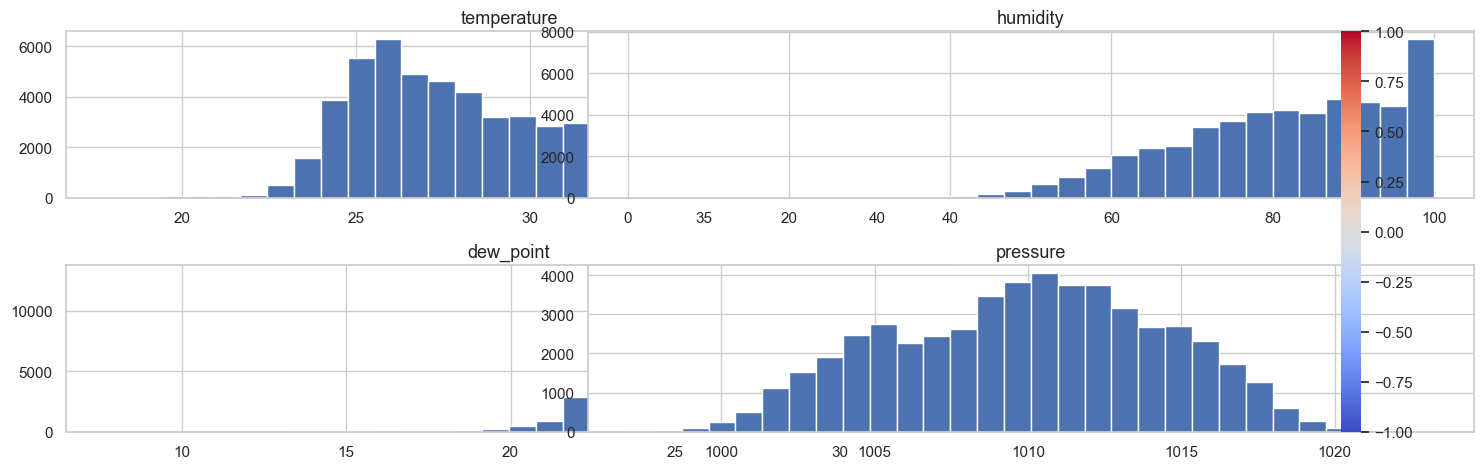

In [6]:
descriptive_stats = analysis_df[weather_cols].describe().T
missing_summary = analysis_df[weather_cols].isna().sum().rename('missing_count').to_frame()
missing_summary['missing_percent'] = missing_summary['missing_count'] / len(analysis_df) * 100

display(descriptive_stats)
display(missing_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
analysis_df[['temperature', 'humidity', 'dew_point', 'pressure']].hist(ax=axes[0], bins=30)
axes[0].set_title('Selected weather-variable distributions')

corr = analysis_df[weather_cols].corr(numeric_only=True)
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, center=0)
axes[1].set_title('Correlation among weather measurements')

plt.tight_layout()
plt.show()


**EDA conclusion:** The cleaned dataset contains complete weather measurements and enough variation to compare thermal comfort, moisture, rainfall, pressure, and UV risk. Correlations are useful for screening relationships, but the project interprets them as associations rather than proof of causation.


## 7. Research Question 1: Temperature and Wind Chill

**Question:** How different are temperature and wind chill readings in Malaysia, and does wind chill provide additional value in a tropical climate?


,Metric,Value
0,Valid rows used,"51,693.000"
1,Mean temperature,28.0646
2,Mean wind chill,28.0616
3,Mean difference: temperature - wind chill,0.0029
4,Median difference,0.0000
5,Correlation,0.9994
6,Rows with exact equality,99.2765%
7,Rows with abs difference <= 0.5 degrees C,99.8143%
8,Rows with abs difference <= 1.0 degrees C,99.9091%
9,Rows with abs difference > 2.0 degrees C,0.0406%


,wind_bin,observations,mean_abs_difference,max_abs_difference
0,0-1,26117,0.003,10.200
1,1-3,11401,0.010,6.100
2,3-5,6182,0.003,4.000
3,5-8,4485,0.001,1.100
4,8+,3508,0.000,0.100


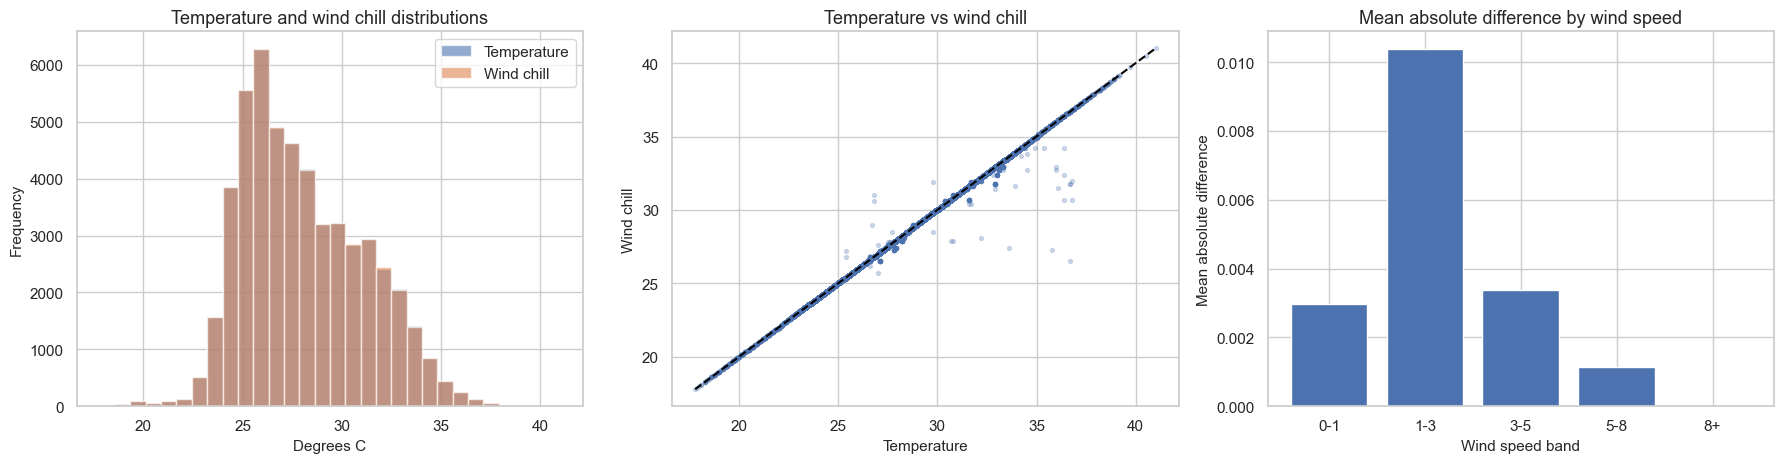

,place,city,state,datetime,temperature,wind_chill,wind_speed,difference,abs_difference,wind_bin
25655,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-24 06:14:59,36.700,26.500,0.400,10.200,10.200,0-1
25661,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-26 04:29:34,35.800,27.300,0.300,8.500,8.500,0-1
25664,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-26 08:59:53,33.600,27.400,0.900,6.200,6.200,0-1
25641,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-22 11:39:33,36.800,30.700,1.700,6.100,6.100,1-3
25701,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-31 11:29:39,36.400,30.700,1.700,5.700,5.700,1-3
25427,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-02-13 14:59:33,36.700,31.800,2.000,4.900,4.900,1-3
25486,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-02-24 14:59:40,36.700,31.800,2.000,4.900,4.900,1-3
25793,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-04-19 11:04:52,36.800,32.000,2.400,4.800,4.800,1-3
25692,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-30 12:04:37,36.100,31.500,0.000,4.600,4.600,0-1
25801,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-04-20 10:34:55,26.800,31.000,1.300,-4.200,4.200,1-3


In [7]:
wind_df = analysis_df[
    ['place', 'city', 'state', 'datetime', 'temperature', 'wind_chill', 'wind_speed']
].copy()
wind_df['difference'] = wind_df['temperature'] - wind_df['wind_chill']
wind_df['abs_difference'] = wind_df['difference'].abs()

wind_metrics = pd.DataFrame({
    'Metric': [
        'Valid rows used',
        'Mean temperature',
        'Mean wind chill',
        'Mean difference: temperature - wind chill',
        'Median difference',
        'Correlation',
        'Rows with exact equality',
        'Rows with abs difference <= 0.5 degrees C',
        'Rows with abs difference <= 1.0 degrees C',
        'Rows with abs difference > 2.0 degrees C',
        'Maximum absolute difference',
        'Rows with non-zero difference',
    ],
    'Value': [
        len(wind_df),
        wind_df['temperature'].mean(),
        wind_df['wind_chill'].mean(),
        wind_df['difference'].mean(),
        wind_df['difference'].median(),
        wind_df['temperature'].corr(wind_df['wind_chill']),
        (wind_df['abs_difference'] == 0).mean(),
        (wind_df['abs_difference'] <= 0.5).mean(),
        (wind_df['abs_difference'] <= 1.0).mean(),
        (wind_df['abs_difference'] > 2.0).mean(),
        wind_df['abs_difference'].max(),
        int((wind_df['abs_difference'] > 0).sum()),
    ]
})

wind_metrics_display = wind_metrics.copy()
wind_metrics_display['Value'] = wind_metrics_display['Value'].astype(object)
for idx in [6, 7, 8, 9]:
    wind_metrics_display.loc[idx, 'Value'] = f"{wind_metrics.loc[idx, 'Value'] * 100:.4f}%"
for idx in [1, 2, 3, 4, 5, 10]:
    wind_metrics_display.loc[idx, 'Value'] = f"{wind_metrics.loc[idx, 'Value']:.4f}"

display(wind_metrics_display)

wind_df['wind_bin'] = pd.cut(
    wind_df['wind_speed'],
    bins=[-0.01, 1, 3, 5, 8, np.inf],
    labels=['0-1', '1-3', '3-5', '5-8', '8+']
)
wind_summary = (
    wind_df.groupby('wind_bin', observed=False)['abs_difference']
    .agg(observations='size', mean_abs_difference='mean', max_abs_difference='max')
    .reset_index()
)
display(wind_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
axes[0].hist(wind_df['temperature'], bins=30, alpha=0.6, label='Temperature')
axes[0].hist(wind_df['wind_chill'], bins=30, alpha=0.6, label='Wind chill')
axes[0].set_title('Temperature and wind chill distributions')
axes[0].set_xlabel('Degrees C')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].scatter(wind_df['temperature'], wind_df['wind_chill'], s=8, alpha=0.25)
min_val = min(wind_df['temperature'].min(), wind_df['wind_chill'].min())
max_val = max(wind_df['temperature'].max(), wind_df['wind_chill'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[1].set_title('Temperature vs wind chill')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Wind chill')

axes[2].bar(wind_summary['wind_bin'].astype(str), wind_summary['mean_abs_difference'])
axes[2].set_title('Mean absolute difference by wind speed')
axes[2].set_xlabel('Wind speed band')
axes[2].set_ylabel('Mean absolute difference')

plt.tight_layout()
plt.show()

non_zero_wind = wind_df.loc[wind_df['abs_difference'] > 0].sort_values('abs_difference', ascending=False)
display(non_zero_wind.head(10))


**Section conclusion:** Temperature and wind chill are almost identical in the cleaned Malaysian weather dataset. Wind chill therefore adds little practical value for routine public communication. Temperature should remain the main thermal headline, while warm-weather comfort should be explained using moisture or heat-discomfort indicators.


## 8. Research Question 2: Humidity, Dew Point, and Oppressive Weather

**Question:** How strongly are humidity and dew point associated, and which variable better describes oppressive weather conditions?


,count,mean,std,min,25%,50%,75%,max
temperature,"51,693.000",28.065,3.076,17.800,25.700,27.500,30.300,41.000
humidity,"51,693.000",81.344,13.448,0.000,72.000,83.000,93.000,100.000
dew_point,"51,693.000",24.259,1.887,7.700,23.300,24.100,25.000,32.200


,Metric,Value
0,Valid rows used,"51,693.000"
1,Mean humidity,81.344
2,Mean dew point,24.259
3,Pearson correlation: humidity vs dew point,0.315
4,Spearman correlation: humidity vs dew point,0.268
5,Share with humidity >= 80%,57.48%
6,Share with dew point >= 24 degrees C,57.08%
7,Share meeting both thresholds,36.10%


,heat_index,humidity,dew_point,temperature
heat_index,1.000,-0.027,0.562,0.769
humidity,-0.027,1.000,0.651,-0.625
dew_point,0.562,0.651,1.000,0.100
temperature,0.769,-0.625,0.100,1.000


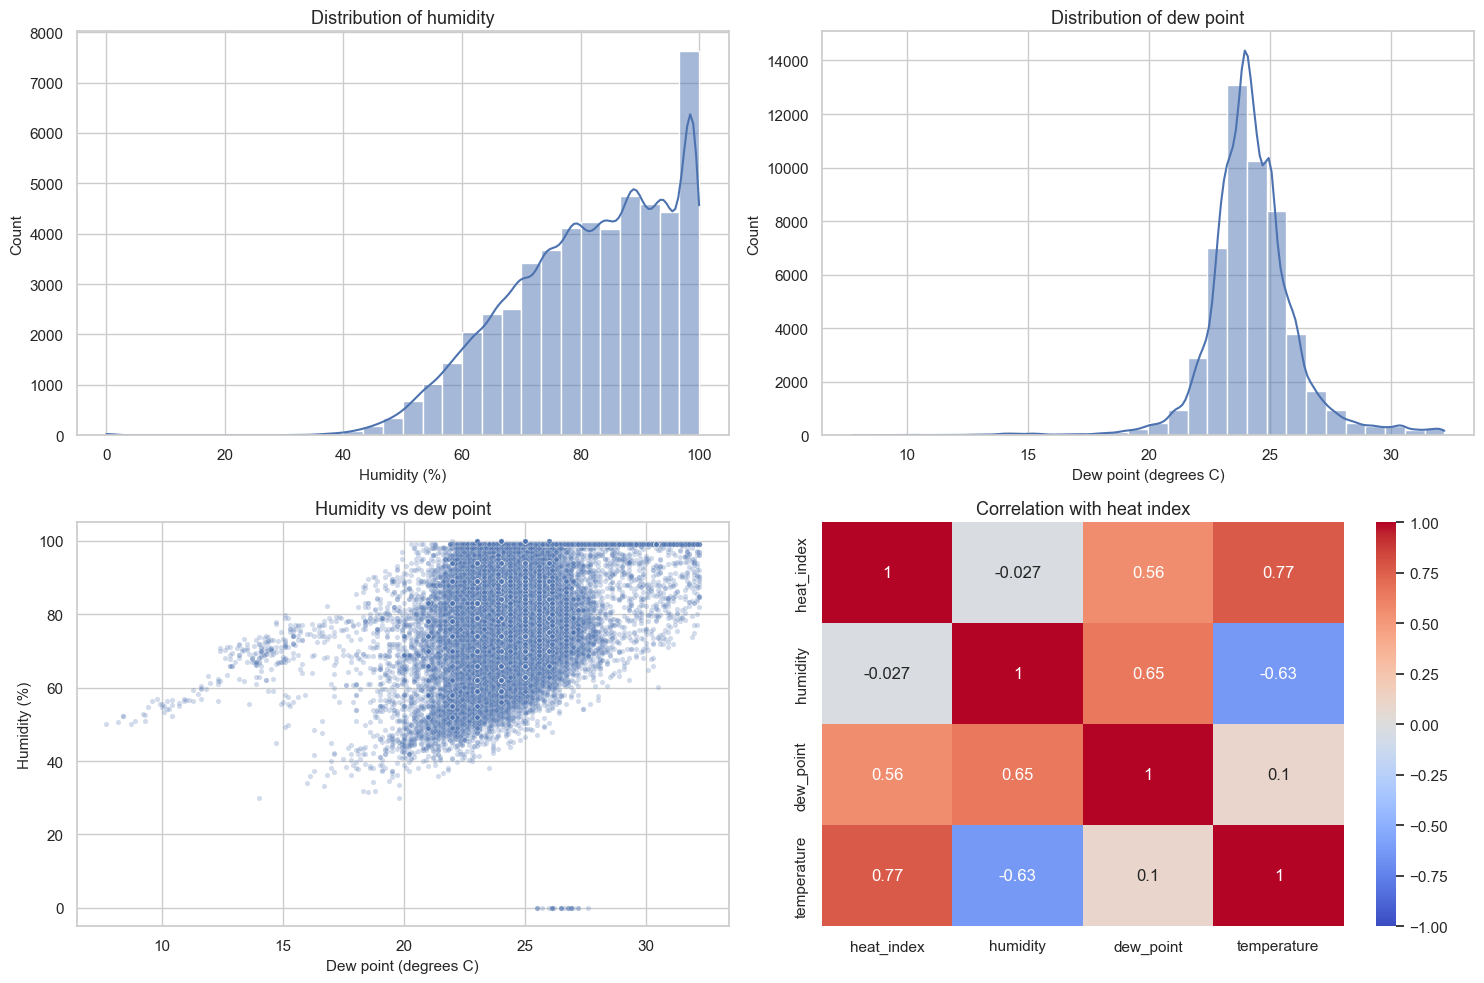

,records,mean_temperature,mean_humidity,mean_dew_point,oppressive_dew_point_rate
state,,,,,
Pulau Pinang,14533,28.074,81.694,24.461,0.702
Kuala Lumpur,37160,28.061,81.207,24.181,0.519


In [8]:
humidity_df = analysis_df[['datetime', 'city', 'state', 'temperature', 'humidity', 'dew_point', 'heat_index']].copy()
humidity_df['oppressive_dew_point'] = humidity_df['dew_point'] >= 24
humidity_df['high_humidity'] = humidity_df['humidity'] >= 80

humidity_summary = humidity_df[['temperature', 'humidity', 'dew_point']].describe().T

dew_humidity_metrics = pd.DataFrame({
    'Metric': [
        'Valid rows used',
        'Mean humidity',
        'Mean dew point',
        'Pearson correlation: humidity vs dew point',
        'Spearman correlation: humidity vs dew point',
        'Share with humidity >= 80%',
        'Share with dew point >= 24 degrees C',
        'Share meeting both thresholds',
    ],
    'Value': [
        len(humidity_df),
        humidity_df['humidity'].mean(),
        humidity_df['dew_point'].mean(),
        humidity_df['humidity'].corr(humidity_df['dew_point']),
        humidity_df['humidity'].corr(humidity_df['dew_point'], method='spearman'),
        humidity_df['high_humidity'].mean(),
        humidity_df['oppressive_dew_point'].mean(),
        (humidity_df['high_humidity'] & humidity_df['oppressive_dew_point']).mean(),
    ]
})

dew_humidity_display = dew_humidity_metrics.copy()
dew_humidity_display['Value'] = dew_humidity_display['Value'].astype(object)
for idx in [5, 6, 7]:
    dew_humidity_display.loc[idx, 'Value'] = f"{dew_humidity_metrics.loc[idx, 'Value'] * 100:.2f}%"
for idx in [1, 2, 3, 4]:
    dew_humidity_display.loc[idx, 'Value'] = f"{dew_humidity_metrics.loc[idx, 'Value']:.3f}"

display(humidity_summary)
display(dew_humidity_display)

warm_weather = humidity_df[(humidity_df['temperature'] >= 27) & (humidity_df['humidity'] >= 40)].copy()
heat_index_corr = warm_weather[['heat_index', 'humidity', 'dew_point', 'temperature']].corr()
display(heat_index_corr)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(humidity_df['humidity'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of humidity')
axes[0, 0].set_xlabel('Humidity (%)')

sns.histplot(humidity_df['dew_point'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of dew point')
axes[0, 1].set_xlabel('Dew point (degrees C)')

sns.scatterplot(data=humidity_df, x='dew_point', y='humidity', alpha=0.25, s=14, ax=axes[1, 0])
axes[1, 0].set_title('Humidity vs dew point')
axes[1, 0].set_xlabel('Dew point (degrees C)')
axes[1, 0].set_ylabel('Humidity (%)')

sns.heatmap(heat_index_corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation with heat index')

plt.tight_layout()
plt.show()

state_comfort_summary = (
    humidity_df.groupby('state')
    .agg(
        records=('humidity', 'size'),
        mean_temperature=('temperature', 'mean'),
        mean_humidity=('humidity', 'mean'),
        mean_dew_point=('dew_point', 'mean'),
        oppressive_dew_point_rate=('oppressive_dew_point', 'mean'),
    )
    .sort_values('mean_dew_point', ascending=False)
)
display(state_comfort_summary)


**Section conclusion:** Humidity and dew point are related, but they are not interchangeable. Relative humidity is strongly shaped by temperature, while dew point more directly reflects moisture in the air. Dew point is therefore the better single indicator for describing muggy or oppressive weather, with humidity kept as supporting context.


## 9. Research Question 3: Pressure, Pressure Trend, and Rainfall

**Question:** How are pressure changes associated with rainfall, and can falling pressure support short-term rainfall guidance?


,count,mean,std,min,25%,50%,75%,max
pressure,"51,661.000","1,009.955",4.420,996.950,"1,006.496","1,010.160","1,013.225","1,023.230"
pressure_change_1obs,"51,661.000",-0.000,1.680,-6.775,-1.000,0.000,1.010,7.150
pressure_change_3obs,"51,629.000",-0.000,2.050,-10.000,-1.405,0.000,1.440,8.980
precipitation_rate,"51,661.000",0.310,3.792,0.000,0.000,0.000,0.000,432.590


,records,current_rain_rate,next_observation_rain_rate,mean_pressure,mean_pressure_change
pressure_trend,,,,,
Falling,23558,24.75%,27.57%,"1,009.393",-1.388
Stable/Rising,28103,28.00%,25.67%,"1,010.426",1.163


,precipitation_rate,rain_event,next_rain_event
pressure,0.018,0.068,0.063
pressure_change_1obs,0.001,0.013,-0.036
pressure_change_3obs,-0.006,-0.030,-0.035
temperature,-0.071,-0.146,-0.063
humidity,0.070,0.206,0.133
wind_speed,0.019,-0.013,0.006
precipitation_rate,1.000,0.136,0.111
rain_event,0.136,1.000,0.626
next_rain_event,0.111,0.626,1.000


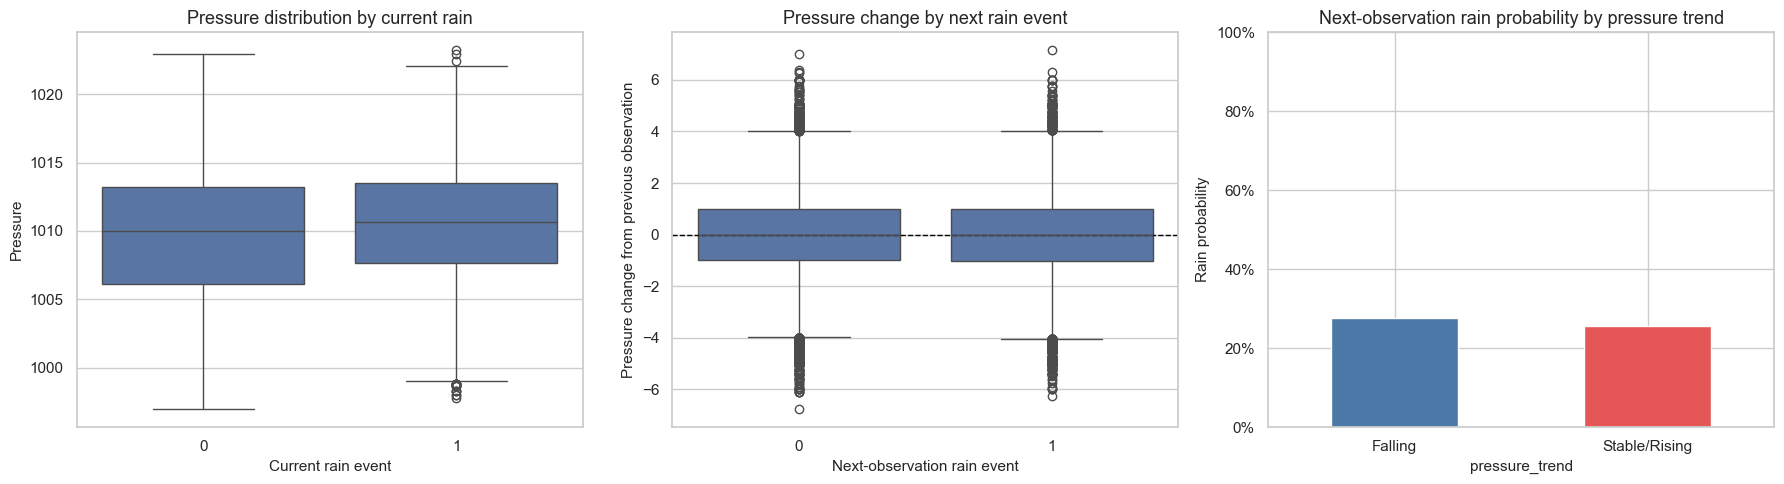

In [9]:
pressure_df = analysis_df.dropna(subset=['pressure_change_1obs', 'next_rain_event']).copy()
pressure_df['next_rain_event'] = pressure_df['next_rain_event'].astype(int)
pressure_df['pressure_trend'] = np.where(pressure_df['pressure_change_1obs'] < 0, 'Falling', 'Stable/Rising')

pressure_stats = pressure_df[
    ['pressure', 'pressure_change_1obs', 'pressure_change_3obs', 'precipitation_rate']
].describe().T

trend_summary = (
    pressure_df.groupby('pressure_trend')
    .agg(
        records=('rain_event', 'size'),
        current_rain_rate=('rain_event', 'mean'),
        next_observation_rain_rate=('next_rain_event', 'mean'),
        mean_pressure=('pressure', 'mean'),
        mean_pressure_change=('pressure_change_1obs', 'mean'),
    )
)
trend_display = trend_summary.copy()
for col in ['current_rain_rate', 'next_observation_rain_rate']:
    trend_display[col] = trend_display[col].map(lambda x: f'{x:.2%}')

display(pressure_stats)
display(trend_display)

pressure_corr = pressure_df[[
    'pressure', 'pressure_change_1obs', 'pressure_change_3obs',
    'temperature', 'humidity', 'wind_speed', 'precipitation_rate',
    'rain_event', 'next_rain_event'
]].corr(numeric_only=True)
display(pressure_corr[['precipitation_rate', 'rain_event', 'next_rain_event']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=pressure_df, x='rain_event', y='pressure', ax=axes[0])
axes[0].set_title('Pressure distribution by current rain')
axes[0].set_xlabel('Current rain event')
axes[0].set_ylabel('Pressure')

sns.boxplot(data=pressure_df, x='next_rain_event', y='pressure_change_1obs', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pressure change by next rain event')
axes[1].set_xlabel('Next-observation rain event')
axes[1].set_ylabel('Pressure change from previous observation')

trend_summary['next_observation_rain_rate'].plot(kind='bar', ax=axes[2], color=['#4c78a8', '#e45756'])
axes[2].set_title('Next-observation rain probability by pressure trend')
axes[2].set_ylabel('Rain probability')
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [10]:
model_results = None
feature_importance = None

if SKLEARN_AVAILABLE:
    model_features = [
        'pressure', 'pressure_change_1obs', 'pressure_change_3obs',
        'temperature', 'humidity', 'dew_point', 'wind_speed',
        'falling_pressure', 'hour_sin', 'hour_cos'
    ]
    rain_model_df = analysis_df.dropna(subset=model_features + ['next_rain_event']).copy()
    rain_model_df['next_rain_event'] = rain_model_df['next_rain_event'].astype(int)

    X = rain_model_df[model_features]
    y = rain_model_df['next_rain_event']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    rain_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    )
    rain_model.fit(X_train, y_train)

    y_probability = rain_model.predict_proba(X_test)[:, 1]
    y_pred = (y_probability >= 0.50).astype(int)
    baseline_pred = np.zeros_like(y_test)

    model_results = pd.DataFrame({
        'Metric': [
            'Test rows', 'Positive class rate in test set',
            'Model accuracy', 'Model precision', 'Model recall', 'Model F1',
            'Model ROC-AUC', 'Model average precision',
            'No-rain baseline accuracy', 'No-rain baseline recall'
        ],
        'Value': [
            len(y_test),
            y_test.mean(),
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, y_probability),
            average_precision_score(y_test, y_probability),
            accuracy_score(y_test, baseline_pred),
            recall_score(y_test, baseline_pred, zero_division=0),
        ]
    })

    display(model_results)

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual no next rain', 'Actual next rain'],
        columns=['Predicted no next rain', 'Predicted next rain']
    )
    display(cm)

    logistic_model = rain_model.named_steps['logisticregression']
    feature_importance = (
        pd.Series(logistic_model.coef_[0], index=model_features, name='standardised_logistic_coefficient')
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame()
    )
    display(feature_importance)
else:
    print('scikit-learn is not installed, so the rainfall model was skipped.')


,Metric,Value
0,Test rows,"12,908.000"
1,Positive class rate in test set,0.265
2,Model accuracy,0.647
3,Model precision,0.395
4,Model recall,0.622
5,Model F1,0.483
6,Model ROC-AUC,0.685
7,Model average precision,0.431
8,No-rain baseline accuracy,0.735
9,No-rain baseline recall,0.000


,Predicted no next rain,Predicted next rain
Actual no next rain,6223,3260
Actual next rain,1296,2129


,standardised_logistic_coefficient
hour_cos,-0.606
temperature,-0.425
hour_sin,-0.403
humidity,0.367
dew_point,0.190
pressure,0.087
pressure_change_1obs,-0.059
wind_speed,0.057
falling_pressure,0.037
pressure_change_3obs,-0.002


**Section conclusion:** Pressure has a measurable but modest association with rainfall. Falling pressure is useful as supporting evidence for rainfall risk, especially when combined with humidity, temperature, wind, and time features. It should not be used as a standalone public warning trigger.


## 10. Research Question 4: UV Index Conditions and Warning Thresholds

**Question:** Which weather conditions correspond to high UV Index values, and at what threshold should public UV warnings be issued?


,Metric,Value
0,Rows analysed,"51,693.000"
1,Rows where UV Index = 0,"33,777.000"
2,Rows where UV Index > 0,"17,916.000"
3,Rows where UV Index >= 6,"4,918.000"
4,Rows where UV Index >= 8,"2,235.000"
5,Maximum UV Index,16.000


,uv_category,records,average_uv,median_uv,daylight_records,share_of_records,share_of_daylight_uv_records
0,Low (0-2),40854,0.249,0.000,7077,79.0%,39.5%
1,Moderate (3-5),5916,3.824,4.000,5916,11.4%,33.0%
2,High (6-7),2682,6.491,6.000,2682,5.2%,15.0%
3,Very high (8-10),1724,8.722,9.000,1724,3.3%,9.6%
4,Extreme (11+),517,11.685,11.000,517,1.0%,2.9%


,hour,records,mean_uv,median_uv,max_uv,warning_rate_ge6,very_high_rate_ge8
10,10,2142,3.337,3.000,11.000,0.171,0.023
11,11,2129,4.634,5.000,13.000,0.413,0.170
12,12,2209,5.046,5.000,14.000,0.468,0.249
13,13,2161,5.077,5.000,16.000,0.441,0.257
14,14,2165,4.278,4.000,14.000,0.370,0.196
15,15,2162,3.335,3.000,12.000,0.235,0.092
16,16,2117,2.031,1.000,8.000,0.045,0.002


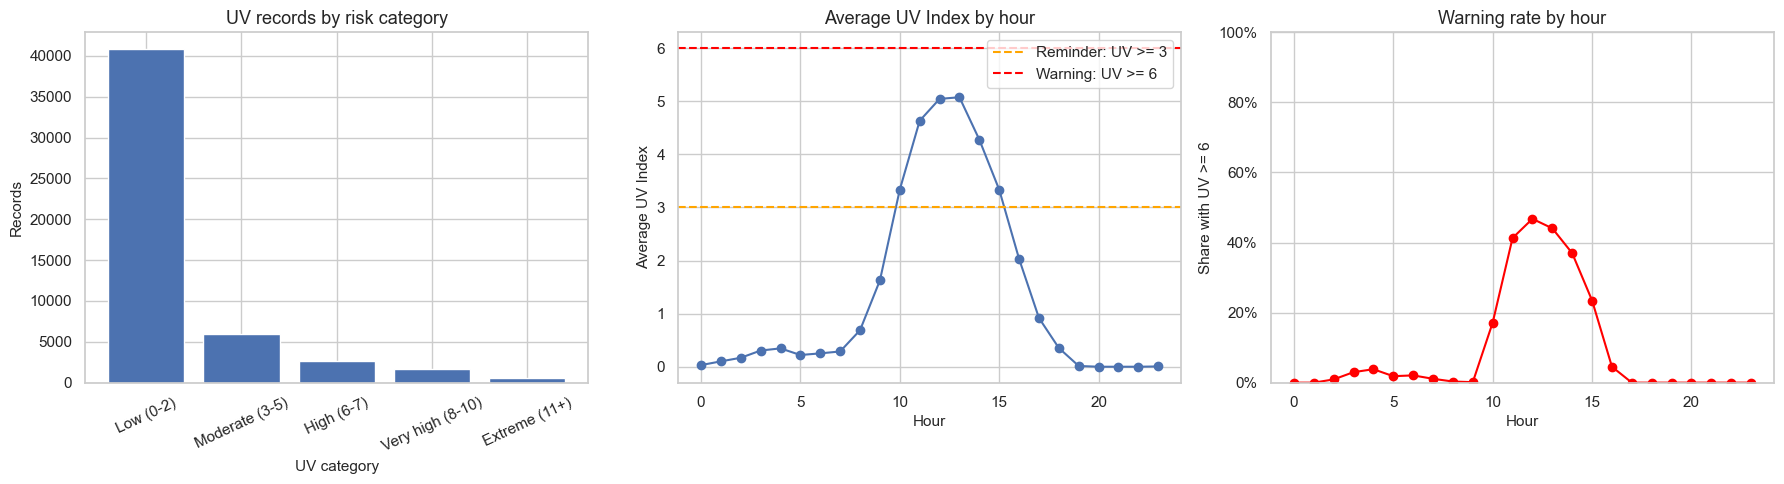

In [11]:
uv_df = analysis_df.copy()
uv_bins = [-0.1, 2, 5, 7, 10, np.inf]
uv_labels = ['Low (0-2)', 'Moderate (3-5)', 'High (6-7)', 'Very high (8-10)', 'Extreme (11+)']
uv_df['uv_category'] = pd.cut(uv_df['uv_index'], bins=uv_bins, labels=uv_labels)
uv_df['daylight_uv'] = uv_df['uv_index'] > 0
uv_df['sun_protection_needed'] = uv_df['uv_index'] >= 3
uv_df['public_warning'] = uv_df['uv_index'] >= 6
uv_df['very_high_alert'] = uv_df['uv_index'] >= 8
uv_df['extreme_alert'] = uv_df['uv_index'] >= 11
uv_df['wet_weather'] = uv_df['precipitation_rate'] > 0

uv_summary = pd.DataFrame({
    'Metric': [
        'Rows analysed',
        'Rows where UV Index = 0',
        'Rows where UV Index > 0',
        'Rows where UV Index >= 6',
        'Rows where UV Index >= 8',
        'Maximum UV Index',
    ],
    'Value': [
        len(uv_df),
        int((uv_df['uv_index'] == 0).sum()),
        int(uv_df['daylight_uv'].sum()),
        int(uv_df['public_warning'].sum()),
        int(uv_df['very_high_alert'].sum()),
        uv_df['uv_index'].max(),
    ]
})

display(uv_summary)

category_summary = (
    uv_df.groupby('uv_category', observed=False)
    .agg(
        records=('uv_index', 'size'),
        average_uv=('uv_index', 'mean'),
        median_uv=('uv_index', 'median')
    )
    .reset_index()
)
daylight_counts = (
    uv_df.loc[uv_df['daylight_uv']]
    .groupby('uv_category', observed=False)
    .size()
    .reindex(category_summary['uv_category'])
    .fillna(0)
    .astype(int)
    .to_numpy()
)
category_summary['daylight_records'] = daylight_counts
category_summary['share_of_records'] = category_summary['records'] / len(uv_df)
category_summary['share_of_daylight_uv_records'] = category_summary['daylight_records'] / uv_df['daylight_uv'].sum()

category_display = category_summary.copy()
for col in ['share_of_records', 'share_of_daylight_uv_records']:
    category_display[col] = category_display[col].map(lambda x: f'{x:.1%}')
display(category_display)

hour_summary = (
    uv_df.groupby('hour')
    .agg(
        records=('uv_index', 'size'),
        mean_uv=('uv_index', 'mean'),
        median_uv=('uv_index', 'median'),
        max_uv=('uv_index', 'max'),
        warning_rate_ge6=('public_warning', 'mean'),
        very_high_rate_ge8=('very_high_alert', 'mean')
    )
    .reset_index()
)
main_warning_window = hour_summary[hour_summary['hour'].between(10, 16)].copy()
display(main_warning_window)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(category_summary['uv_category'].astype(str), category_summary['records'])
axes[0].set_title('UV records by risk category')
axes[0].set_xlabel('UV category')
axes[0].set_ylabel('Records')
axes[0].tick_params(axis='x', rotation=25)

axes[1].plot(hour_summary['hour'], hour_summary['mean_uv'], marker='o')
axes[1].axhline(3, linestyle='--', color='orange', label='Reminder: UV >= 3')
axes[1].axhline(6, linestyle='--', color='red', label='Warning: UV >= 6')
axes[1].set_title('Average UV Index by hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average UV Index')
axes[1].legend()

axes[2].plot(hour_summary['hour'], hour_summary['warning_rate_ge6'], marker='o', color='red')
axes[2].set_title('Warning rate by hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Share with UV >= 6')
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()


,uv_category,records,median_uv,mean_temperature,median_temperature,mean_humidity,median_humidity,mean_dew_point,median_pressure,median_wind_speed,wet_weather_rate,median_hour
0,Low (0-2),40854,0.000,27.207,26.800,84.541,86.800,24.158,"1,010.160",0.500,5.1%,10.000
1,Moderate (3-5),5916,4.000,30.925,31.000,72.005,71.150,24.818,"1,009.990",2.800,2.1%,12.000
2,High (6-7),2682,6.000,31.725,31.900,66.143,66.000,24.410,"1,011.680",3.400,0.5%,12.000
3,Very high (8-10),1724,9.000,31.689,32.000,65.916,66.000,24.380,"1,011.010",4.600,0.6%,12.000
4,Extreme (11+),517,11.000,32.044,32.000,65.915,66.000,24.741,"1,009.820",7.000,0.8%,13.000


,correlation_with_uv_index
humidity,-0.489
precipitation_total,-0.042
precipitation_rate,-0.026
month_number,-0.022
pressure,0.049
hour,0.054
dew_point,0.097
gust,0.354
wind_speed,0.392
temperature,0.559


,threshold,category_level,records,share_of_records,share_of_daylight_uv_records,share_occurring_between_10_and_16,recommended_client_action
0,UV Index >= 3,Moderate or above,10741,20.8%,60.0%,87.2%,Show sun-protection reminder
1,UV Index >= 6,High or above,4918,9.5%,27.5%,94.2%,Issue public UV warning
2,UV Index >= 8,Very high or above,2235,4.3%,12.5%,95.8%,Escalate warning / extra protection
3,UV Index >= 11,Extreme,511,1.0%,2.9%,95.5%,Urgent extreme UV alert


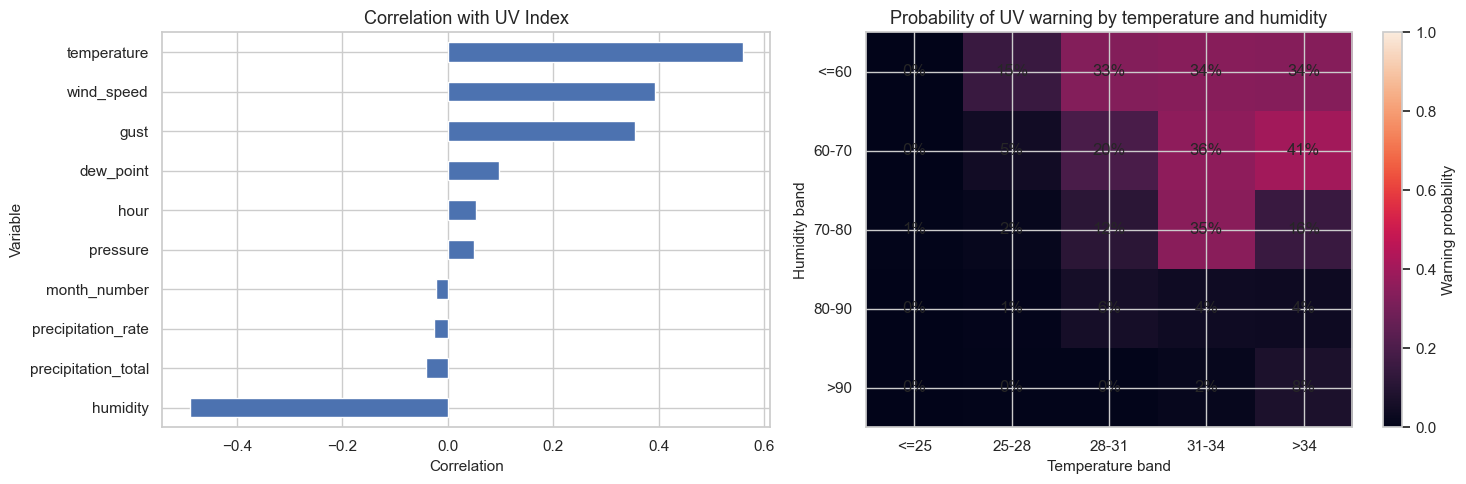

In [12]:
condition_summary = (
    uv_df.groupby('uv_category', observed=False)
    .agg(
        records=('uv_index', 'size'),
        median_uv=('uv_index', 'median'),
        mean_temperature=('temperature', 'mean'),
        median_temperature=('temperature', 'median'),
        mean_humidity=('humidity', 'mean'),
        median_humidity=('humidity', 'median'),
        mean_dew_point=('dew_point', 'mean'),
        median_pressure=('pressure', 'median'),
        median_wind_speed=('wind_speed', 'median'),
        wet_weather_rate=('wet_weather', 'mean'),
        median_hour=('hour', 'median'),
    )
    .reset_index()
)
condition_display = condition_summary.copy()
condition_display['wet_weather_rate'] = condition_display['wet_weather_rate'].map(lambda x: f'{x:.1%}')
display(condition_display)

corr_vars = [
    'uv_index', 'temperature', 'humidity', 'dew_point', 'pressure', 'wind_speed',
    'gust', 'precipitation_rate', 'precipitation_total', 'hour', 'month_number'
]
correlation_with_uv = (
    uv_df[corr_vars]
    .corr(numeric_only=True)['uv_index']
    .drop('uv_index')
    .sort_values()
)
display(correlation_with_uv.to_frame('correlation_with_uv_index'))

uv_df['temperature_bin'] = pd.cut(
    uv_df['temperature'],
    bins=[-np.inf, 25, 28, 31, 34, np.inf],
    labels=['<=25', '25-28', '28-31', '31-34', '>34']
)
uv_df['humidity_bin'] = pd.cut(
    uv_df['humidity'],
    bins=[-np.inf, 60, 70, 80, 90, np.inf],
    labels=['<=60', '60-70', '70-80', '80-90', '>90']
)
risk_grid = (
    uv_df.dropna(subset=['temperature_bin', 'humidity_bin'])
    .groupby(['humidity_bin', 'temperature_bin'], observed=False)['public_warning']
    .mean()
    .unstack()
)

threshold_rows = []
for threshold, label, client_action in [
    (3, 'Moderate or above', 'Show sun-protection reminder'),
    (6, 'High or above', 'Issue public UV warning'),
    (8, 'Very high or above', 'Escalate warning / extra protection'),
    (11, 'Extreme', 'Urgent extreme UV alert'),
]:
    mask = uv_df['uv_index'] >= threshold
    threshold_rows.append({
        'threshold': f'UV Index >= {threshold}',
        'category_level': label,
        'records': int(mask.sum()),
        'share_of_records': mask.mean(),
        'share_of_daylight_uv_records': mask.sum() / uv_df['daylight_uv'].sum(),
        'share_occurring_between_10_and_16': uv_df.loc[mask, 'hour'].between(10, 16).mean(),
        'recommended_client_action': client_action,
    })
threshold_summary = pd.DataFrame(threshold_rows)
threshold_display = threshold_summary.copy()
for col in ['share_of_records', 'share_of_daylight_uv_records', 'share_occurring_between_10_and_16']:
    threshold_display[col] = threshold_display[col].map(lambda x: f'{x:.1%}')
display(threshold_display)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
correlation_with_uv.plot(kind='barh', ax=axes[0])
axes[0].set_title('Correlation with UV Index')
axes[0].set_xlabel('Correlation')
axes[0].set_ylabel('Variable')

image = axes[1].imshow(risk_grid, aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Probability of UV warning by temperature and humidity')
axes[1].set_xlabel('Temperature band')
axes[1].set_ylabel('Humidity band')
axes[1].set_xticks(range(len(risk_grid.columns)))
axes[1].set_yticks(range(len(risk_grid.index)))
axes[1].set_xticklabels(risk_grid.columns)
axes[1].set_yticklabels(risk_grid.index)
for row in range(risk_grid.shape[0]):
    for col in range(risk_grid.shape[1]):
        value = risk_grid.iloc[row, col]
        if pd.notna(value):
            axes[1].text(col, row, f'{value:.0%}', ha='center', va='center')
fig.colorbar(image, ax=axes[1], label='Warning probability')

plt.tight_layout()
plt.show()


**Section conclusion:** High UV values are concentrated from late morning to mid-afternoon and occur most often in warmer, less humid, low-rainfall conditions. The UV Index should be communicated directly: use UV >= 3 for a reminder, UV >= 6 for a public warning, and UV >= 8 for a stronger alert.


## 11. Executive Summary and Client Recommendations

The integrated analysis supports a practical public weather communication strategy.


In [13]:
pressure_next_falling = trend_summary.loc['Falling', 'next_observation_rain_rate'] if 'Falling' in trend_summary.index else np.nan
pressure_next_stable = trend_summary.loc['Stable/Rising', 'next_observation_rain_rate'] if 'Stable/Rising' in trend_summary.index else np.nan
rain_auc = None
if model_results is not None:
    rain_auc = float(model_results.loc[model_results['Metric'] == 'Model ROC-AUC', 'Value'].iloc[0])

recommendations = pd.DataFrame({
    'Indicator': ['Temperature', 'Wind chill', 'Dew point', 'Humidity', 'Pressure trend', 'UV Index'],
    'Evidence from analysis': [
        f"Mean temperature is {wind_df['temperature'].mean():.2f} degrees C in the cleaned dataset.",
        f"{(wind_df['abs_difference'] == 0).mean() * 100:.2f}% of temperature/wind-chill records are exactly equal.",
        f"{humidity_df['oppressive_dew_point'].mean() * 100:.2f}% of records have dew point >= 24 degrees C.",
        f"Humidity-dew point Pearson correlation is {humidity_df['humidity'].corr(humidity_df['dew_point']):.3f}.",
        f"Next-observation rain probability is {pressure_next_falling:.2%} after falling pressure versus {pressure_next_stable:.2%} after stable/rising pressure; model ROC-AUC is {rain_auc:.3f}.",
        f"UV >= 6 occurs in {threshold_summary.loc[threshold_summary['threshold'] == 'UV Index >= 6', 'share_of_records'].iloc[0]:.1%} of records and is concentrated between 10:00 and 16:00.",
    ],
    'Recommendation': [
        'Use as the main thermal headline.',
        'Do not emphasise for routine Malaysian public guidance.',
        'Use as the main moisture/discomfort indicator.',
        'Keep as supporting context because it is temperature-dependent.',
        'Use as a supporting rainfall-risk signal, not a standalone forecast.',
        'Always show in daylight when available and issue warnings at UV >= 6.',
    ]
})
recommendations


,Indicator,Evidence from analysis,Recommendation
0,Temperature,Mean temperature is 28.06 degrees C in the cle...,Use as the main thermal headline.
1,Wind chill,99.28% of temperature/wind-chill records are e...,Do not emphasise for routine Malaysian public ...
2,Dew point,57.08% of records have dew point >= 24 degrees C.,Use as the main moisture/discomfort indicator.
3,Humidity,Humidity-dew point Pearson correlation is 0.315.,Keep as supporting context because it is tempe...
4,Pressure trend,Next-observation rain probability is 27.57% af...,"Use as a supporting rainfall-risk signal, not ..."
5,UV Index,UV >= 6 occurs in 9.5% of records and is conce...,Always show in daylight when available and iss...


## 12. Overall Conclusions

The project shows that a useful Malaysian public weather service should prioritise variables that lead to clear interpretation and practical public action.

**Answers to the research questions:**

1. **Temperature and wind chill:** Wind chill adds little value because it is almost always equal to temperature in the cleaned dataset. Temperature should remain the main thermal indicator.
2. **Humidity and dew point:** Dew point is more useful than humidity alone for describing oppressive weather because it reflects actual moisture in the air and relates more clearly to heat discomfort.
3. **Pressure and rainfall:** Pressure trend has some value for upcoming rain guidance, especially when combined with other weather variables. It should be used as a supporting signal, not as a single warning trigger.
4. **UV Index:** High UV is concentrated around late morning and early afternoon. Public communication should use UV Index directly, with reminders at UV >= 3, warnings at UV >= 6, and stronger alerts at UV >= 8.

**Final client recommendation:** A public weather dashboard for Malaysia should prioritise temperature, dew point or heat discomfort, rainfall risk, and UV Index. Wind chill can be de-emphasised, while pressure trend can appear as supporting rainfall context.


## 13. Limitations

- The cleaned file contains no missing values, so this notebook cannot distinguish original observations from values that were imputed during the cleaning stage.
- The dataset covers the available observations only and does not represent every Malaysian location equally.
- Important meteorological variables such as cloud cover, solar radiation, monsoon phase, and direct human comfort ratings are not included.
- The pressure model predicts next-observation rain, but observation gaps are not always equal, so it is a practical indicator rather than a precise forecast model.
- Correlation and logistic regression show associations, not causal relationships.
- UV warning thresholds are based on standard public-health categories, but a real warning system should verify local operational requirements before deployment.


## 14. References

- World Health Organization (2022) *Radiation: The ultraviolet (UV) index*. Available at: https://www.who.int/news-room/questions-and-answers/item/radiation-the-ultraviolet-%28uv%29-index
- World Health Organization (2022) *Ultraviolet radiation*. Available at: https://www.who.int/news-room/fact-sheets/detail/ultraviolet-radiation
- United States Environmental Protection Agency (2026) *UV Index Scale*. Available at: https://www.epa.gov/sunsafety/uv-index-scale-0
- National Environment Agency Singapore (n.d.) *Ultraviolet Index*. Available at: https://www.nea.gov.sg/corporate-functions/weather/ultraviolet-index
